In [121]:
import scanpy as sc
import decoupler as dc
import numpy as np
import pandas as pd
import anndata as ad
from scipy.stats import median_abs_deviation

In [122]:
"""
preprocessing_v_0_2.py
======================
Single-cell RNA-seq preprocessing pipeline for brain dataset analysis.
Designed for GSE138852 (Alzheimer's) and GSE175583 (brain cell types).

Research question: What transcriptional and regulatory changes define
the transition from healthy to disease-associated cell states in human
brain, and which transcription factors are causal drivers?

"""

import logging
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
from scipy.stats import median_abs_deviation

# ── Logging setup ────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger(__name__)

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


# ── Data loading ─────────────────────────────────────────────────────────────

def load_data(counts_path: str, covariates_path: str) -> ad.AnnData:
    """
    Load counts and covariate CSVs into an AnnData object.

    Parameters
    ----------
    counts_path : str
        Path to gene counts CSV (genes x cells).
    covariates_path : str
        Path to cell metadata CSV (cells x covariates).

    Returns
    -------
    ad.AnnData
        AnnData object with cells as observations.
    """
    log.info(f"Loading counts from {counts_path}")
    var = pd.read_csv(counts_path, index_col=0)
    obs = pd.read_csv(covariates_path, index_col=0)
    var.index = var.index.astype(str)
    var.columns = var.columns.astype(str)
    obs.index = obs.index.astype(str)
    obs.columns = obs.columns.astype(str)
    adata = ad.AnnData(var.T, obs)
    log.info(f"Loaded {adata.n_obs} cells x {adata.n_vars} genes")
    return adata


# ── QC ────────────────────────────────────────────────────────────────────────

def simple_qc(adata: ad.AnnData, mad_threshold: float = 3,
              max_mt_pct: float = 20.0) -> ad.AnnData:
    """
    Filter low-quality cells using MAD-based thresholds on gene counts
    and mitochondrial read percentage.

    Parameters
    ----------
    adata : AnnData
        Raw count matrix.
    mad_threshold : float
        Number of MADs below the median to set the lower gene count limit.
    max_mt_pct : float
        Hard upper cap on mitochondrial percentage (default 20%).

    Returns
    -------
    AnnData
        Filtered AnnData with low-quality cells removed.
    """
    log.info("Running QC filtering...")

    adata.var["mt"] = adata.var_names.str.startswith(("MT-", "mt-"))

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt"],
        percent_top=None,
        log1p=False,
        inplace=True
    )

    # Gene count filter — MAD-based lower bound
    n_genes_median = np.median(adata.obs["n_genes_by_counts"])
    n_genes_mad = median_abs_deviation(adata.obs["n_genes_by_counts"])
    lower_gene_limit = np.maximum(
        n_genes_median - (mad_threshold * n_genes_mad), 100
    )

    # MT filter — MAD-based upper bound, capped by hard limit
    mt_median = np.median(adata.obs["pct_counts_mt"])
    mt_mad = median_abs_deviation(adata.obs["pct_counts_mt"])
    upper_mt_limit = np.minimum(
        mt_median + (mad_threshold * mt_mad), max_mt_pct
    )

    cells_before = adata.n_obs
    adata = adata[
        (adata.obs["n_genes_by_counts"] > lower_gene_limit) &
        (adata.obs["pct_counts_mt"] < upper_mt_limit),
        :
    ].copy()

    sc.pp.filter_genes(adata, min_cells=3)

    log.info(f"QC Summary:")
    log.info(f"  Min genes threshold : {lower_gene_limit:.1f}")
    log.info(f"  Max MT%  threshold  : {upper_mt_limit:.2f}%")
    log.info(f"  Cells removed       : {cells_before - adata.n_obs}")
    log.info(f"  Cells remaining     : {adata.n_obs}")
    log.info(f"  Genes remaining     : {adata.n_vars}")

    return adata


# ── Doublet detection ─────────────────────────────────────────────────────────

def _find_metadata_column(adata: ad.AnnData,
                          keywords: list[str] = None) -> tuple:
    """
    Search obs columns for existing doublet annotations.

    Returns
    -------
    tuple : (column_name, matching_labels) or (None, None)
    """
    if keywords is None:
        keywords = ["doublet", "db"]

    for col in adata.obs.columns:
        if any(key in col.lower() for key in keywords):
            return col, None

        if adata.obs[col].nunique() < 50:
            unique_values = adata.obs[col].unique().astype(str)
            matching_labels = [
                val for val in unique_values
                if any(k in val.lower() for k in keywords)
            ]
            if matching_labels:
                log.info(
                    f"Found doublet labels {matching_labels} in column '{col}'"
                )
                return col, matching_labels

    return None, None


def doublet_detection(adata: ad.AnnData, remove: bool = True,
                      threshold: float = None) -> ad.AnnData:
    """
    Detect and optionally remove doublets.

    Uses existing metadata if available; falls back to Scrublet simulation.

    Parameters
    ----------
    adata : AnnData
        Filtered count matrix (post-QC).
    remove : bool
        If True, remove detected doublets from the dataset.
    threshold : float or None
        Scrublet score threshold. If None, determined automatically.

    Returns
    -------
    AnnData
        AnnData with 'is_doublet' column added to obs.
    """
    log.info("Running doublet detection...")
    col, labels = _find_metadata_column(adata)

    if col:
        if labels:
            is_doublet = adata.obs[col].isin(labels)
        else:
            is_doublet = adata.obs[col].astype(str).str.contains(
                "doublet|db", case=False
            )
        log.info(f"Using existing doublet metadata from column: '{col}'")
        adata.obs["is_doublet"] = is_doublet
    else:
        log.info("No doublet metadata found — running Scrublet simulation...")
        sc.pp.scrublet(adata, threshold=threshold, random_state=RANDOM_SEED)
        adata.obs["is_doublet"] = adata.obs["predicted_doublet"]

    n_doublets = adata.obs["is_doublet"].sum()
    doublet_rate = (n_doublets / adata.n_obs) * 100
    log.info(
        f"Doublets detected: {n_doublets} ({doublet_rate:.2f}% of cells)"
    )

    if remove:
        adata = adata[~adata.obs["is_doublet"]].copy()
        log.info(f"Doublets removed. Cells remaining: {adata.n_obs}")

    return adata


# ── Feature selection ──────────────────────────────────────────────────────────

def gene_selection(adata: ad.AnnData, threshold: float = 1.05) -> ad.AnnData:
    """
    Select highly variable genes using Seurat v3 method.

    IMPORTANT: Must be called on raw counts (before normalization).
    Seurat v3 HVG selection requires unnormalized data.

    Parameters
    ----------
    adata : AnnData
        Raw count matrix (post-QC, post-doublet removal).
    threshold : float
        Normalized variance threshold for gene selection.

    Returns
    -------
    AnnData
        AnnData subsetted to highly variable genes, with raw counts stored.
    """
    log.info("Selecting highly variable genes (Seurat v3)...")

    # Store raw counts BEFORE any normalization — used later for DE analysis
    adata.raw = adata

    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3"  
    )

    adata.var["highly_variable"] = adata.var["variances_norm"] > threshold
    num_hvg = adata.var["highly_variable"].sum()
    log.info(
        f"Selected {num_hvg} genes with normalized variance > {threshold}"
    )

    # Subset to HVGs before normalization
    adata = adata[:, adata.var.highly_variable].copy()
    log.info(f"Dataset shape after HVG selection: {adata.shape}")

    adata.layers["counts"] = adata.X.copy()

    return adata


# ── Normalization ──────────────────────────────────────────────────────────────

def normalization(adata: ad.AnnData) -> ad.AnnData:
    """
    Normalize, log-transform, and scale the count matrix.

    Order matters:
      1. normalize_total  — library size correction
      2. log1p            — variance stabilization
      3. scale            — zero mean, unit variance (for PCA only)

    The normalized-but-unscaled values are preserved in adata.layers
    for downstream use (e.g. trajectory inference, DE analysis).

    Parameters
    ----------
    adata : AnnData
        HVG-subsetted count matrix.

    Returns
    -------
    AnnData
        Normalized AnnData. adata.X contains scaled values.
        adata.layers['normalized'] contains log-normalized unscaled values.
    """
    log.info("Normalizing data...")

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    adata.layers["normalized"] = adata.X.copy()

    sc.pp.scale(adata, max_value=10)

    log.info("Normalization complete.")
    log.info("  adata.X              → scaled (for PCA/UMAP)")
    log.info("  adata.layers['normalized'] → log-normalized (for scVelo etc)")
    log.info("  adata.raw            → raw counts (for DE analysis)")
    log.info("  adata.layers['counts'] → filtered DE analysis (decoupler)")

    return adata


# ── Dimensionality reduction ───────────────────────────────────────────────────

def _find_elbow(adata: ad.AnnData, threshold: float = 1e-6,
                fallback_pcs: int = 30) -> int:
    """
    Automatically select number of PCs by finding the elbow in variance ratio.

    Parameters
    ----------
    adata : AnnData
        Must have PCA already computed.
    threshold : float
        Minimum change in variance ratio to detect elbow.
    fallback_pcs : int
        Number of PCs to use if no elbow is detected.

    Returns
    -------
    int
        Number of PCs to use for neighborhood graph.
    """
    variance = adata.uns["pca"]["variance_ratio"]
    diff = np.diff(variance)
    elbow_candidates = np.where(np.abs(diff) < threshold)[0]

    if len(elbow_candidates) == 0:
        log.warning(
            f"No elbow detected at threshold {threshold}. "
            f"Falling back to {fallback_pcs} PCs."
        )
        return fallback_pcs

    elbow_idx = int(elbow_candidates[0])
    return max(elbow_idx, 5)  # never use fewer than 5 PCs


def dim_reduction(adata: ad.AnnData, n_neighbors: int = 15,
                  auto_pc: bool = True) -> ad.AnnData:
    """
    Compute PCA, nearest neighbor graph, and UMAP embedding.

    Parameters
    ----------
    adata : AnnData
        Scaled, normalized AnnData.
    n_neighbors : int
        Number of neighbors for the kNN graph.
    auto_pc : bool
        If True, automatically select number of PCs via elbow detection.

    Returns
    -------
    AnnData
        AnnData with PCA, neighbors, and UMAP computed.
    """
    log.info("Computing PCA...")
    sc.tl.pca(adata, n_comps=100, svd_solver="arpack",
              random_state=RANDOM_SEED)

    if auto_pc:
        n_pcs = _find_elbow(adata)
        log.info(f"Elbow detection selected {n_pcs} PCs")
    else:
        n_pcs = 50
        log.info(f"Using fixed {n_pcs} PCs")

    log.info(f"Building kNN graph (k={n_neighbors}, n_pcs={n_pcs})...")
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs,
                    random_state=RANDOM_SEED)

    log.info("Computing UMAP...")
    sc.tl.umap(adata, random_state=RANDOM_SEED)

    return adata


# ── Full pipeline ──────────────────────────────────────────────────────────────

def run_pipeline(adata: ad.AnnData) -> ad.AnnData:
    """
    Run the full preprocessing pipeline in the correct order:

      QC → doublet removal → HVG selection (raw counts)
      → normalization → dimensionality reduction

    Parameters
    ----------
    adata : AnnData
        Raw count matrix loaded from source data.

    Returns
    -------
    AnnData
        Fully preprocessed AnnData ready for clustering and analysis.
    """
    log.info("=" * 50)
    log.info("Starting preprocessing pipeline v0.2")
    log.info("=" * 50)

    adata = simple_qc(adata)
    adata = doublet_detection(adata)

    # gene_selection MUST come before normalization — Seurat v3 needs raw counts
    adata = gene_selection(adata)
    adata = normalization(adata)
    adata = dim_reduction(adata)

    log.info("=" * 50)
    log.info("Pipeline complete.")
    log.info(f"Final dataset: {adata.n_obs} cells x {adata.n_vars} genes")
    log.info("=" * 50)

    return adata


# ── Entry point ────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    adata = load_data("GSE138852_counts.csv", "GSE138852_covariates.csv")
    adata = run_pipeline(adata)
    #adata.write_h5ad("GSE138852_preprocessed.h5ad")
    #log.info("Saved to GSE138852_preprocessed.h5ad")


20:46:12 [INFO] Loading counts from GSE138852_counts.csv
20:46:43 [INFO] Loaded 13214 cells x 10850 genes
20:46:43 [INFO] ==================================================
20:46:43 [INFO] Starting preprocessing pipeline v0.2
20:46:43 [INFO] ==================================================
20:46:43 [INFO] Running QC filtering...
20:46:50 [INFO] QC Summary:
20:46:50 [INFO]   Min genes threshold : 142.0
20:46:50 [INFO]   Max MT%  threshold  : 0.96%
20:46:50 [INFO]   Cells removed       : 2440
20:46:50 [INFO]   Cells remaining     : 10774
20:46:50 [INFO]   Genes remaining     : 10850
20:46:50 [INFO] Running doublet detection...
20:46:50 [INFO] Found doublet labels ['doublet'] in column 'oupSample.cellType'
20:46:50 [INFO] Using existing doublet metadata from column: 'oupSample.cellType'
20:46:50 [INFO] Doublets detected: 244 (2.26% of cells)
20:46:50 [INFO] Doublets removed. Cells remaining: 10530
20:46:50 [INFO] Selecting highly variable genes (Seurat v3)...
20:46:56 [INFO] Selected 19

In [133]:
adata.obs

,oupSample.batchCond,oupSample.cellType,oupSample.cellType_batchCond,oupSample.subclustID,oupSample.subclustCond,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,is_doublet,leiden,cell_type
AAACCTGGTAGAAAGG_AD5_AD6,AD,oligo,oligo_AD,o3,AD,564,760,3,0.394737,False,0,oligodendrocytes
AAACCTGTCCAAACAC_AD5_AD6,AD,oligo,oligo_AD,o3,AD,615,925,1,0.108108,False,0,oligodendrocytes
AAACCTGTCCAGTATG_AD5_AD6,AD,oligo,oligo_AD,o3,AD,434,562,3,0.533808,False,1,oligodendrocytes
AAAGCAAGTCGAATCT_AD5_AD6,AD,oligo,oligo_AD,o3,AD,431,586,2,0.341297,False,1,oligodendrocytes
AAAGTAGGTAATCACC_AD5_AD6,AD,oligo,oligo_AD,o3,AD,477,661,6,0.907716,False,0,oligodendrocytes
...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTCAGCCTTTC_AD1_AD2,AD,unID,unID_AD,u6,AD,650,851,4,0.470035,False,4,opcs
TTTGGTTCATCGGACC_AD1_AD2,AD,unID,unID_AD,u5,AD,374,455,3,0.659341,False,7,microglia
TTTGGTTTCCCAGGTG_AD1_AD2,AD,oligo,oligo_AD,o1,AD,359,435,4,0.919540,False,1,oligodendrocytes
TTTGGTTTCCGTACAA_AD1_AD2,AD,oligo,oligo_AD,o3,AD,339,442,2,0.452489,False,1,oligodendrocytes


In [123]:
sc.tl.leiden(adata,resolution=0.5,random_state=42,flavor="igraph")

... storing 'oupSample.batchCond' as categorical
... storing 'oupSample.cellType' as categorical
... storing 'oupSample.cellType_batchCond' as categorical
... storing 'oupSample.subclustID' as categorical


... storing 'oupSample.subclustCond' as categorical


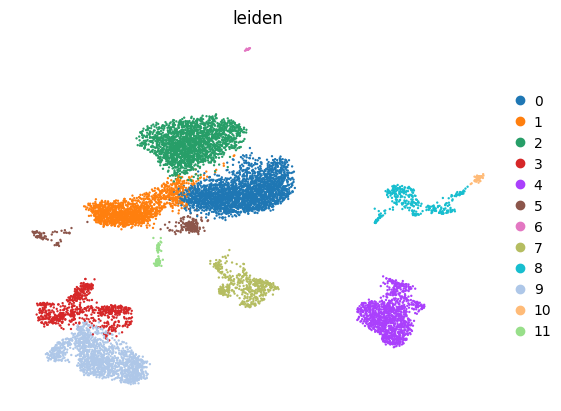

In [124]:
sc.pl.umap(adata,color="leiden",frameon=False)

In [125]:
marker_dict = {
    "Excitatory neurons":  ["CAMK2A", "SLC17A7", "RBFOX1"],
    "Inhibitory neurons":  ["GAD1", "GAD2", "SLC32A1"],
    "Astrocytes":          ["GFAP", "AQP4", "SLC1A2"],
    "Oligodendrocytes":    ["MBP", "MOG", "PLP1"],
    "OPCs":                ["PDGFRA", "OLIG1", "VCAN"],
    "Microglia":           ["CX3CR1", "CSF1R", "P2RY12"],
    "Endothelial":         ["CLDN5", "FLT1"]
}

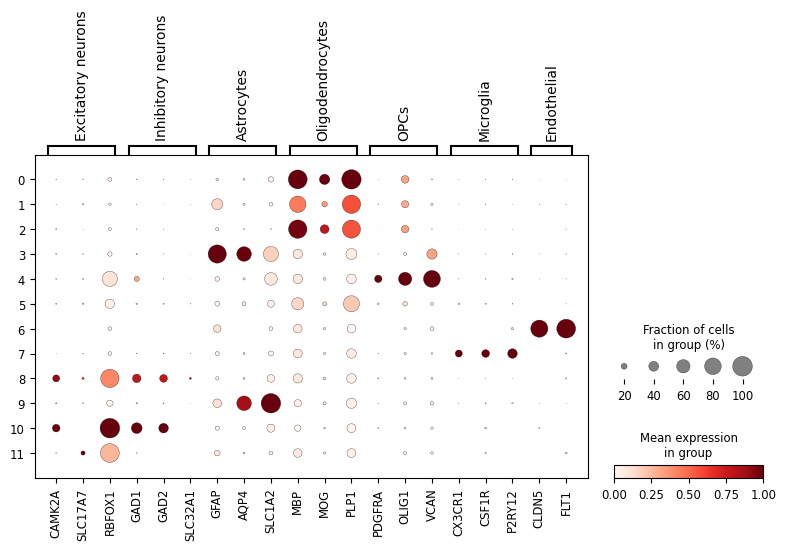

In [126]:
sc.pl.dotplot(
    adata,
    marker_dict,
    groupby="leiden",
    standard_scale="var",
    swap_axes=False
)

In [127]:
cluster_to_celltype = {
    "0":"oligodendrocytes",
    "1":"oligodendrocytes",
    "2":"oligodendrocytes",
    "3":"astrocytes",
    "4":"opcs",
    "5":"oligodendrocytes",
    "6":"endothelial",
    "7":"microglia",
    "8":"neuron",
    "9":"astrocytes",
    "10":"neuron",
    "11":"excitatory neuron"
}

In [128]:
adata.obs["cell_type"] = (
    adata.obs["leiden"]
    .map(cluster_to_celltype)
    .fillna("unknown")
    .astype("category")
)

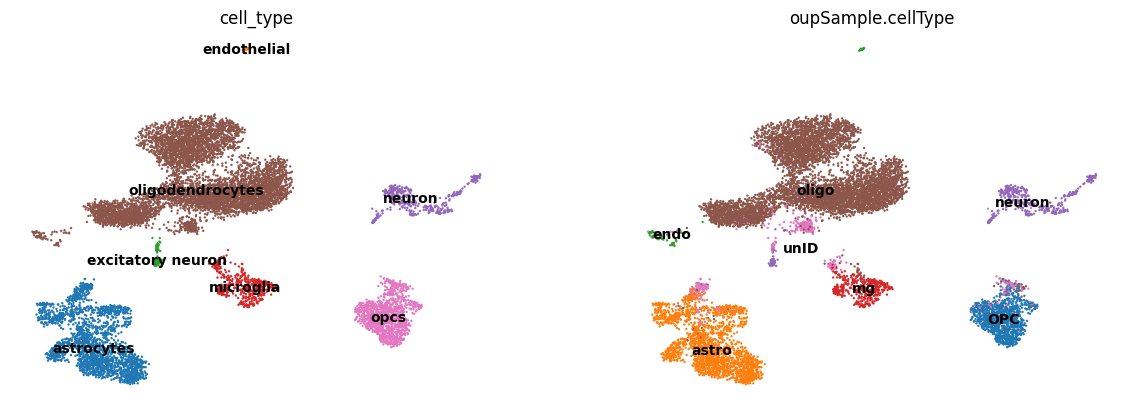

In [129]:
sc.pl.umap(adata,color=["cell_type","oupSample.cellType"],legend_loc="on data",frameon=False)

In [10]:
import decoupler as dc

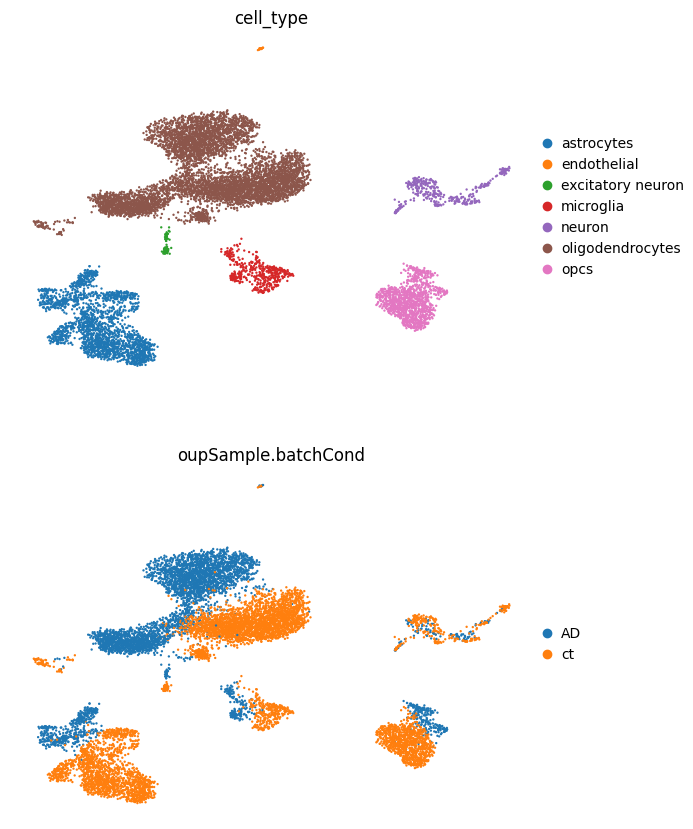

In [130]:
sc.pl.umap(adata, color=["cell_type", "oupSample.batchCond"], ncols=1,frameon=False)

In [131]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    layer="counts",
    sample_col="oupSample.batchCond",
    groups_col="leiden",
    mode="sum",
)

In [132]:
pdata.obs

,oupSample.batchCond,leiden,is_doublet,cell_type,psbulk_cells,psbulk_counts
AD_0,AD,0,False,oligodendrocytes,84.0,14594.0
ct_0,ct,0,False,oligodendrocytes,2481.0,486569.0
AD_1,AD,1,False,oligodendrocytes,1372.0,155649.0
ct_1,ct,1,False,oligodendrocytes,89.0,10050.0
AD_10,AD,10,False,neuron,9.0,5321.0
ct_10,ct,10,False,neuron,40.0,29321.0
AD_11,AD,11,False,excitatory neuron,28.0,4878.0
ct_11,ct,11,False,excitatory neuron,44.0,13157.0
AD_2,AD,2,False,oligodendrocytes,2015.0,429378.0
ct_2,ct,2,False,oligodendrocytes,17.0,2897.0


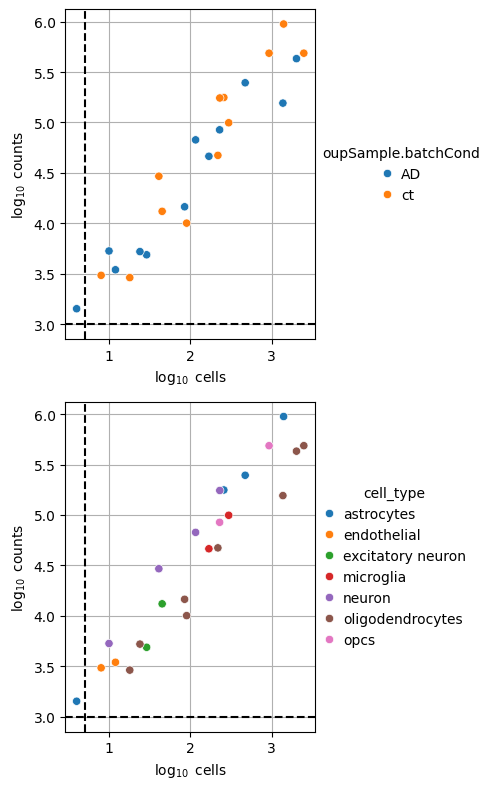

In [133]:
dc.pl.filter_samples(
    adata=pdata,
    groupby=["oupSample.batchCond", "cell_type"],
    min_cells=5,
    min_counts=1000,
    figsize=(5, 8),
)

In [134]:
dc.pp.filter_samples(pdata, min_cells=5, min_counts=1000)

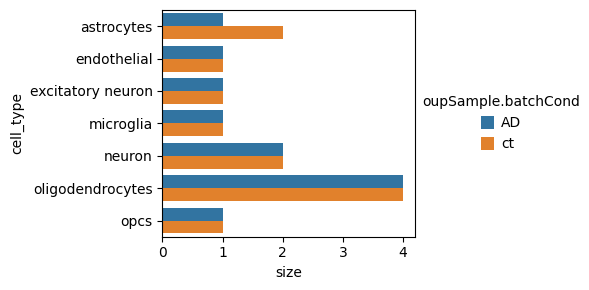

In [135]:
dc.pl.obsbar(adata=pdata, y="cell_type", hue="oupSample.batchCond", figsize=(6, 3))

In [136]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X


In [137]:
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)

In [138]:
pdata.obs.drop(columns="is_doublet",inplace=True)

In [139]:
pdata.obs

,oupSample.batchCond,leiden,cell_type,psbulk_cells,psbulk_counts
AD_0,AD,0,oligodendrocytes,84.0,14594.0
ct_0,ct,0,oligodendrocytes,2481.0,486569.0
AD_1,AD,1,oligodendrocytes,1372.0,155649.0
ct_1,ct,1,oligodendrocytes,89.0,10050.0
AD_10,AD,10,neuron,9.0,5321.0
ct_10,ct,10,neuron,40.0,29321.0
AD_11,AD,11,excitatory neuron,28.0,4878.0
ct_11,ct,11,excitatory neuron,44.0,13157.0
AD_2,AD,2,oligodendrocytes,2015.0,429378.0
ct_2,ct,2,oligodendrocytes,17.0,2897.0


In [140]:
dc.tl.rankby_obsm(pdata, key="X_pca")

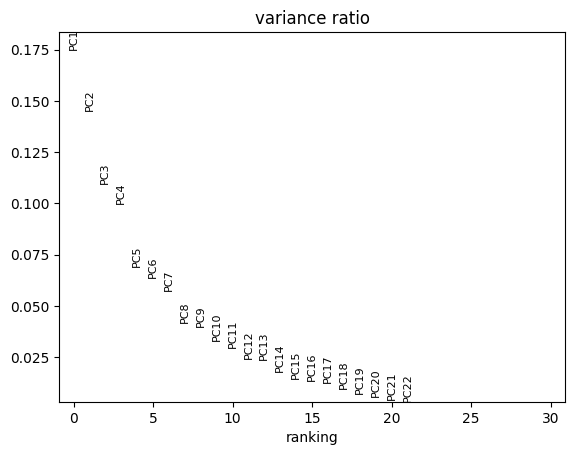

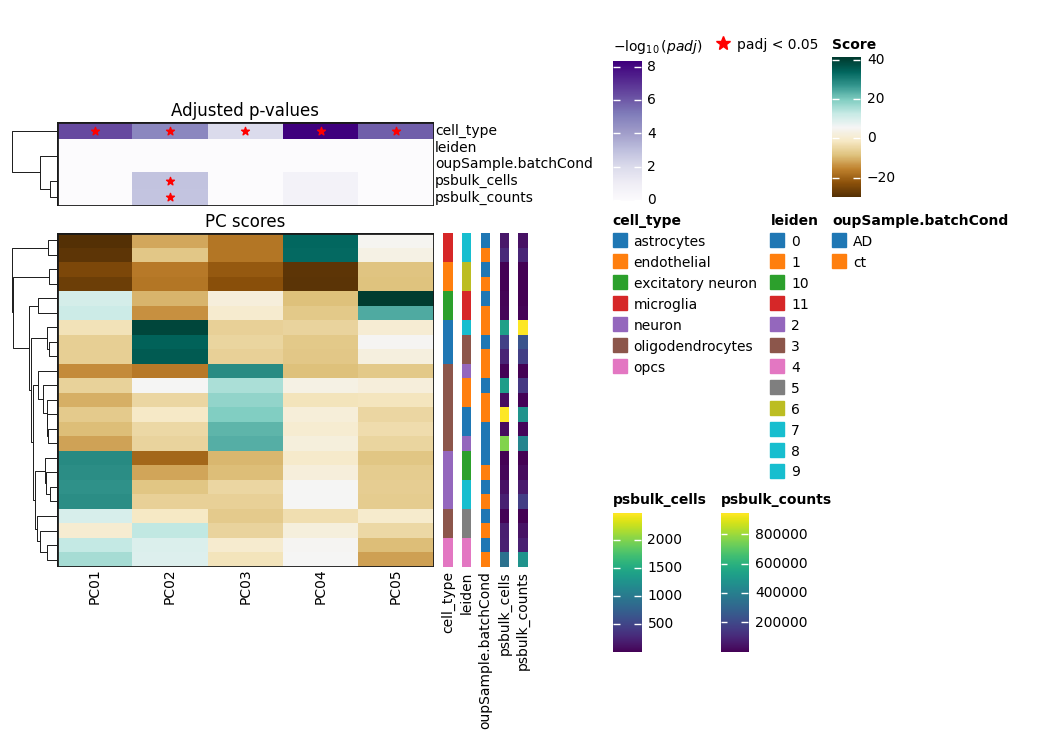

In [141]:
sc.pl.pca_variance_ratio(pdata)
dc.pl.obsm(adata=pdata, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

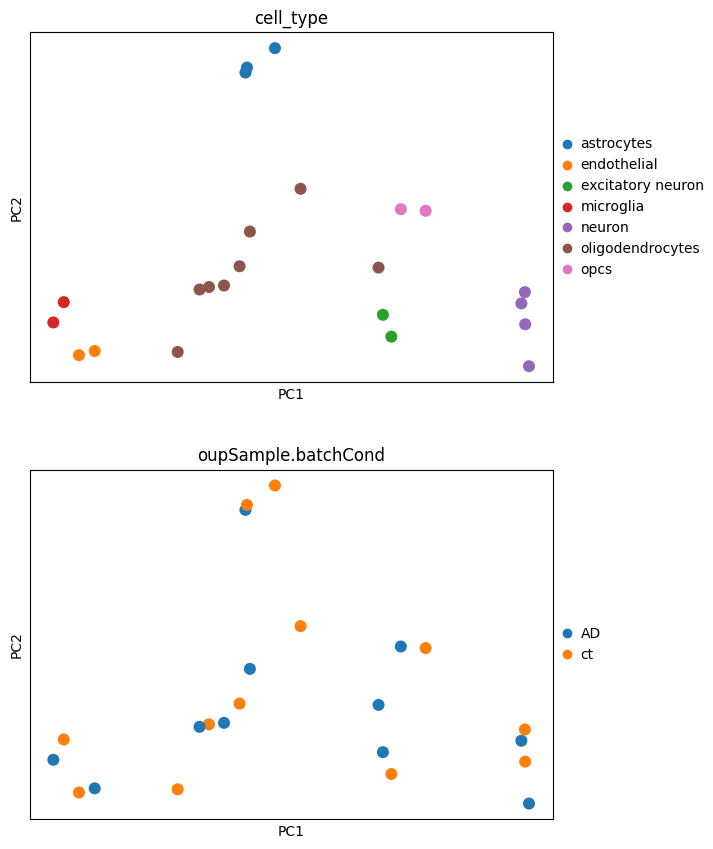

In [142]:
sc.pl.pca(
    pdata,
    color=["cell_type","oupSample.batchCond"],
    ncols=1,
    size=300,
    frameon=True,
)

In [143]:
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [144]:
inference = DefaultInference(n_cpus=8)

In [145]:
pdata.obs["condition"] = pdata.obs["oupSample.batchCond"].astype(str) + pdata.obs["cell_type"].astype(str)

In [146]:
dds = DeseqDataSet(
    adata=pdata,
    design="~condition",
    refit_cooks=True,
    inference=inference,
)


In [147]:
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.59 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.49 seconds.

Fitting LFCs...
... done in 0.59 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [148]:
dds.obs

,oupSample.batchCond,leiden,cell_type,psbulk_cells,psbulk_counts,condition,size_factors,replaceable
AD_0,AD,0,oligodendrocytes,84.0,14594.0,ADoligodendrocytes,0.352362,False
ct_0,ct,0,oligodendrocytes,2481.0,486569.0,ctoligodendrocytes,10.828342,False
AD_1,AD,1,oligodendrocytes,1372.0,155649.0,ADoligodendrocytes,4.543560,False
ct_1,ct,1,oligodendrocytes,89.0,10050.0,ctoligodendrocytes,0.239265,False
AD_10,AD,10,neuron,9.0,5321.0,ADneuron,0.135524,False
ct_10,ct,10,neuron,40.0,29321.0,ctneuron,0.657796,False
AD_11,AD,11,excitatory neuron,28.0,4878.0,ADexcitatory neuron,0.164803,False
ct_11,ct,11,excitatory neuron,44.0,13157.0,ctexcitatory neuron,0.303598,False
AD_2,AD,2,oligodendrocytes,2015.0,429378.0,ADoligodendrocytes,10.574670,False
ct_2,ct,2,oligodendrocytes,17.0,2897.0,ctoligodendrocytes,0.082870,False


In [149]:
import matplotlib.pyplot as plt

Running Wald tests...
... done in 0.25 seconds.



Log2 fold change & Wald test p-value: condition ctoligodendrocytes vs ADoligodendrocytes
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
ISG15       4.630424       -0.337686  1.255675 -0.268928  0.787985  0.999452
HES5        2.292776        3.537686  1.853946  1.908193  0.056366  0.999452
LINC00982   2.764735        0.874465  1.807539  0.483788  0.628536  0.999452
PRDM16      4.951375        0.647150  1.327039  0.487665  0.625787  0.999452
TPRG1L      2.437320       -0.465402  1.630854 -0.285373  0.775358  0.999452
...              ...             ...       ...       ...       ...       ...
DSCAM      89.581431        0.311974  0.744208  0.419203  0.675068  0.999452
TRPM2       5.896765       -0.681048  1.396153 -0.487803  0.625689  0.999452
COL18A1     7.127317       -0.444710  1.058754 -0.420031  0.674463  0.999452
S100B      33.031994        0.450386  0.595742  0.756009  0.449644  0.999452
MT-ND3     32.569321       -0.122545  0.570288 -0.214882  0.8298

Running Wald tests...
... done in 0.22 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition ctneuron vs ADneuron
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
ISG15       4.630424       -0.438429  1.949776 -0.224861  0.822087  0.999421
HES5        2.292776        2.277731  2.894755  0.786848  0.431371  0.999421
LINC00982   2.764735       -3.039366  3.297251 -0.921788  0.356639  0.999421
PRDM16      4.951375       -0.389317  2.186321 -0.178069  0.858669  0.999421
TPRG1L      2.437320        0.124210  2.634728  0.047143  0.962399  0.999421
...              ...             ...       ...       ...       ...       ...
DSCAM      89.581431       -0.717466  0.973733 -0.736820  0.461232  0.999421
TRPM2       5.896765       -0.530751  1.606535 -0.330370  0.741121  0.999421
COL18A1     7.127317       -0.328847  1.630865 -0.201640  0.840198  0.999421
S100B      33.031994        0.722258  1.080699  0.668325  0.503926  0.999421
MT-ND3     32.569321        0.233496  0.938027  0.248922  0.803421  0.999421

[1985 

... done in 0.25 seconds.

Running Wald tests...


...

Log2 fold change & Wald test p-value: condition ctopcs vs ADopcs
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
ISG15       4.630424        1.508048  2.241494  0.672787  0.501083  0.999413
HES5        2.292776        4.117250  3.185770  1.292388  0.196223  0.999413
LINC00982   2.764735       -1.374591  2.884314 -0.476575  0.633665  0.999413
PRDM16      4.951375       -1.237089  2.088547 -0.592321  0.553636  0.999413
TPRG1L      2.437320       -0.152201  2.915830 -0.052198  0.958371  0.999413
...              ...             ...       ...       ...       ...       ...
DSCAM      89.581431        0.213060  1.323329  0.161003  0.872091  0.999413
TRPM2       5.896765       -1.374592  2.162723 -0.635584  0.525048  0.999413
COL18A1     7.127317       -0.374593  2.017617 -0.185661  0.852710  0.999413
S100B      33.031994        0.756480  1.116991  0.677248  0.498248  0.999413
MT-ND3     32.569321       -1.409926  1.057028 -1.333858  0.182250  0.999413

[1985 rows

... done in 0.22 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition ctendothelial vs ADendothelial
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
ISG15       4.630424       -0.136262  2.937925 -0.046380  0.963007  0.991506
HES5        2.292776       -0.136262  5.538526 -0.024603  0.980372  0.991506
LINC00982   2.764735       -0.136262  5.516282 -0.024702  0.980293  0.991506
PRDM16      4.951375       -0.136262  5.136830 -0.026526  0.978837  0.991506
TPRG1L      2.437320       -2.578949  4.588706 -0.562021  0.574102  0.991506
...              ...             ...       ...       ...       ...       ...
DSCAM      89.581431       -1.136261  2.207029 -0.514838  0.606667  0.991506
TRPM2       5.896765       -2.578953  4.127153 -0.624875  0.532053  0.991506
COL18A1     7.127317       -4.163913  3.944557 -1.055610  0.291147  0.991506
S100B      33.031994        2.306425  3.820195  0.603745  0.546013  0.991506
MT-ND3     32.569321       -0.551300  1.510188 -0.365054  0.715071  0.9915

... done in 0.26 seconds.



Log2 fold change & Wald test p-value: condition ctmicroglia vs ADmicroglia
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
ISG15       4.630424       -1.917633  2.490611 -0.769945  0.441333  0.998011
HES5        2.292776        2.110014  4.516700  0.467158  0.640387  0.998011
LINC00982   2.764735       -2.332666  3.304684 -0.705867  0.480271  0.998011
PRDM16      4.951375       -0.332674  2.305983 -0.144265  0.885291  0.998011
TPRG1L      2.437320       -1.917631  3.064975 -0.625660  0.531538  0.998011
...              ...             ...       ...       ...       ...       ...
DSCAM      89.581431       -1.381171  1.335636 -1.034092  0.301093  0.998011
TRPM2       5.896765       -0.747710  1.941678 -0.385085  0.700175  0.998011
COL18A1     7.127317       -0.217196  2.014308 -0.107826  0.914133  0.998011
S100B      33.031994        1.291817  1.265071  1.021142  0.307187  0.998011
MT-ND3     32.569321       -1.892100  1.118221 -1.692063  0.090634  0.998011



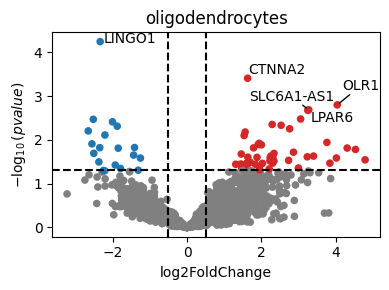

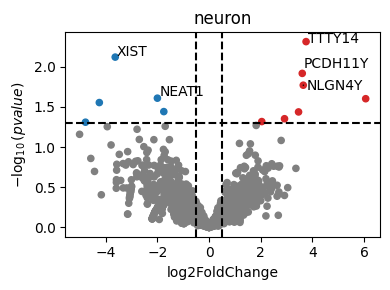

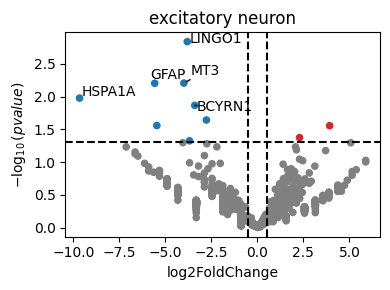

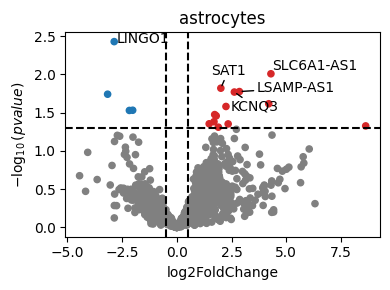

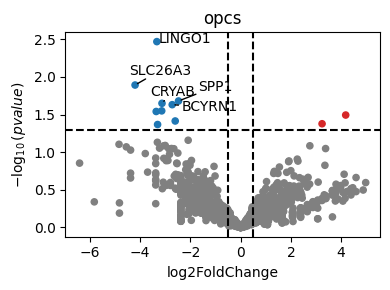

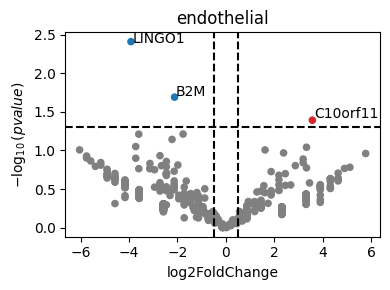

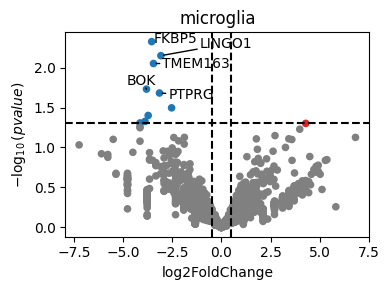

In [150]:
for ct in pdata.obs["cell_type"].unique():
    stat_res = DeseqStats(dds, contrast=["condition",f"ct{ct}",f"AD{ct}"], inference=inference)
    stat_res.summary()
    results_df = stat_res.results_df
    dc.pl.volcano(results_df, x="log2FoldChange", y="pvalue")
    plt.title(f"{ct}")

In [151]:
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


C:\Users\Asus\AppData\Local\Temp\ipykernel_1468\637608522.py:20: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  gex_ct = ct_cond_adata.to_df().mean(0).to_frame().T
C:\Users\Asus\AppData\Local\Temp\ipykernel_1468\637608522.py:22: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  score_ct = score.to_df().mean(0).to_frame().T
C:\Users\Asus\AppData\Local\Temp\ipykernel_1468\637608522.py:20: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  gex_ct = ct_cond_adata.to_df().mean(0).to_frame().T
C:\Users\Asus\AppData\Local\Temp\ipykernel_1468\637608522.py:22: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  score_ct = score.to_df().mean(0).to_frame().T
C:\Users\Asus\AppData\Local\Temp\ipykernel_1468\637608522.py:20: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  gex_

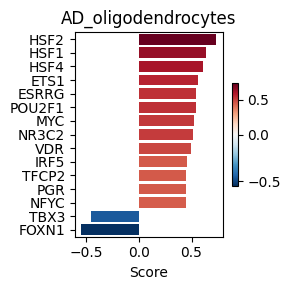

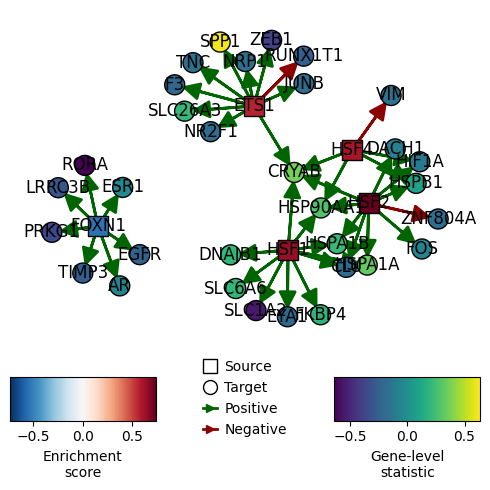

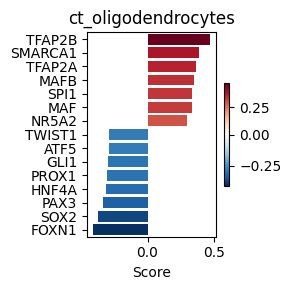

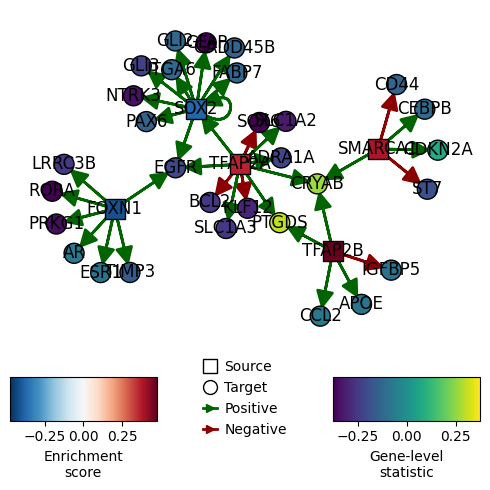

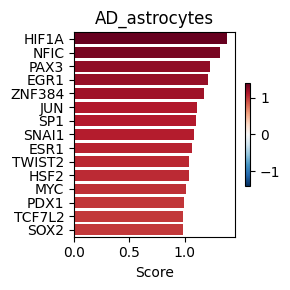

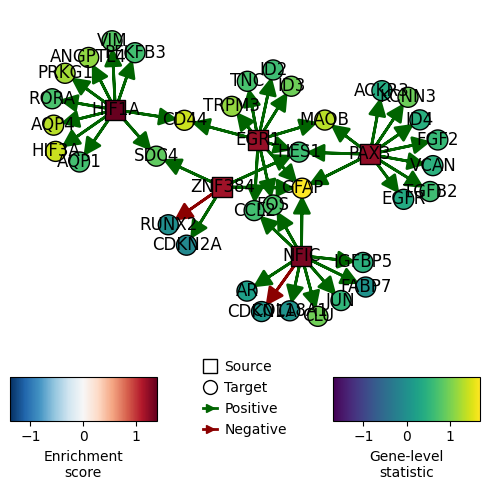

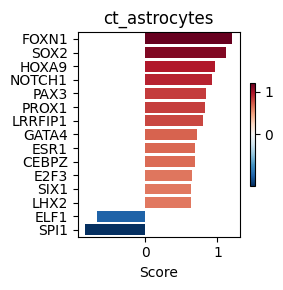

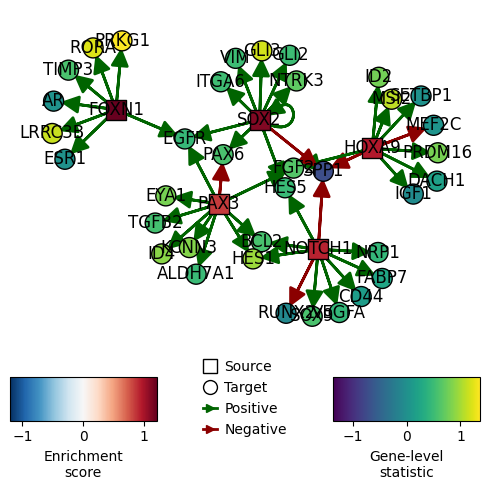

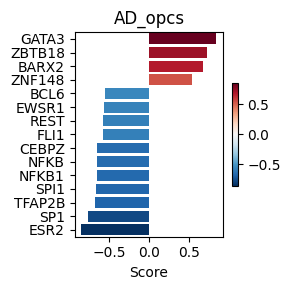

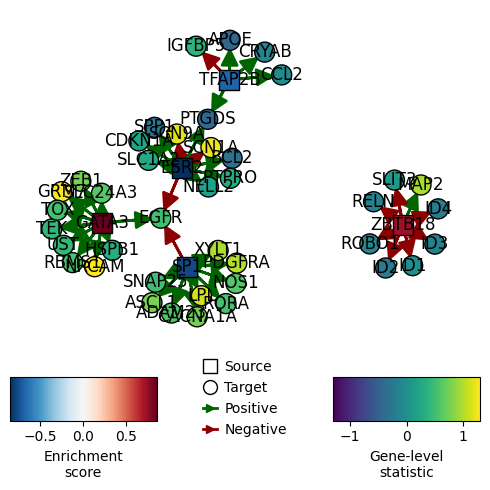

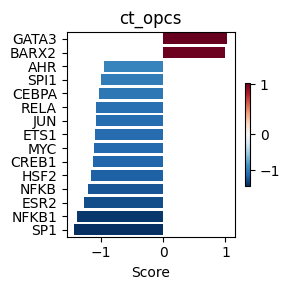

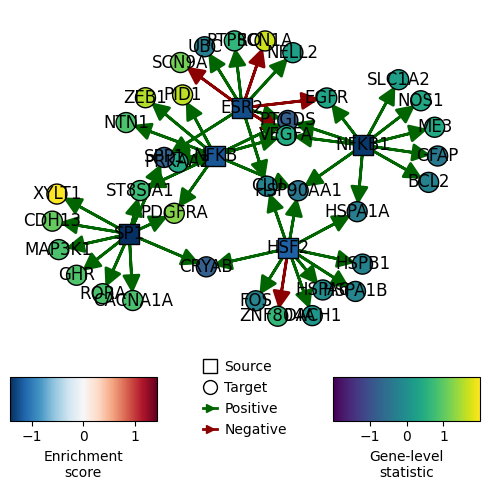

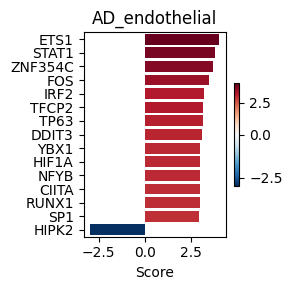

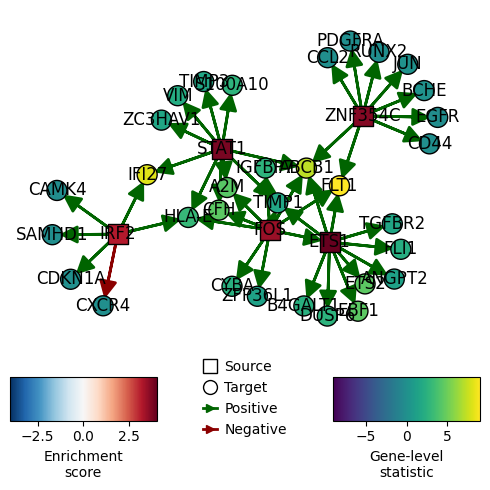

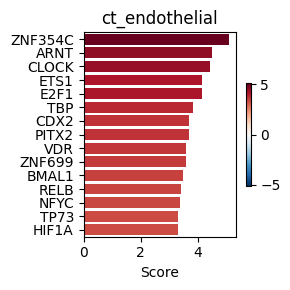

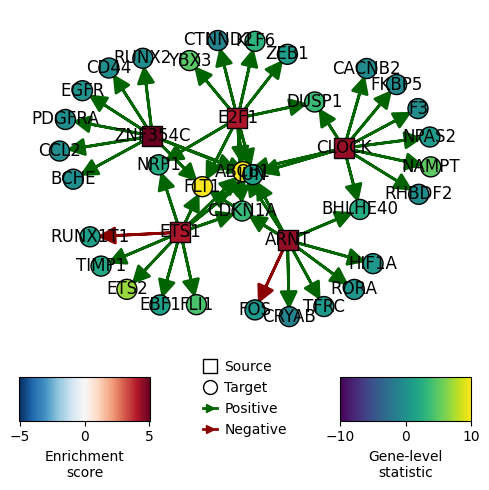

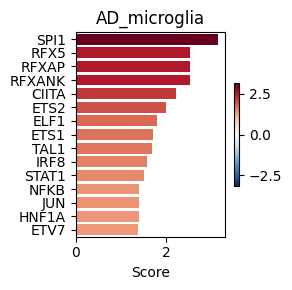

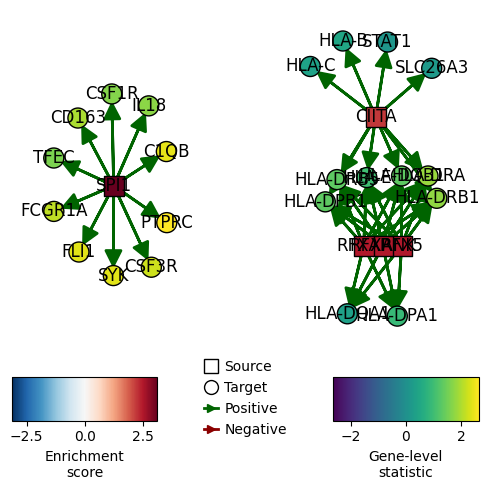

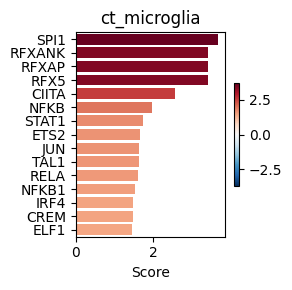

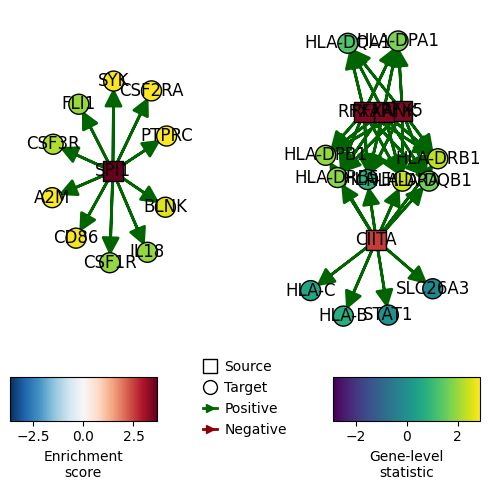

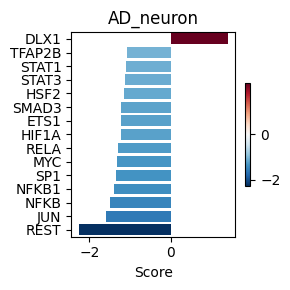

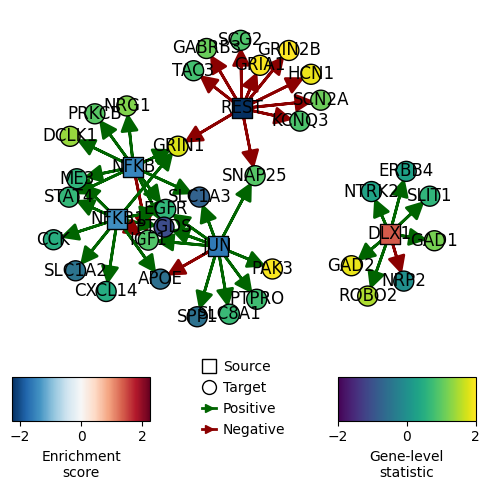

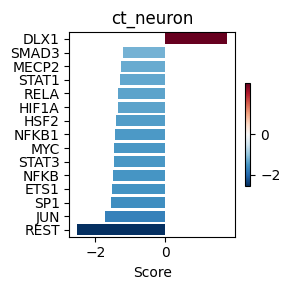

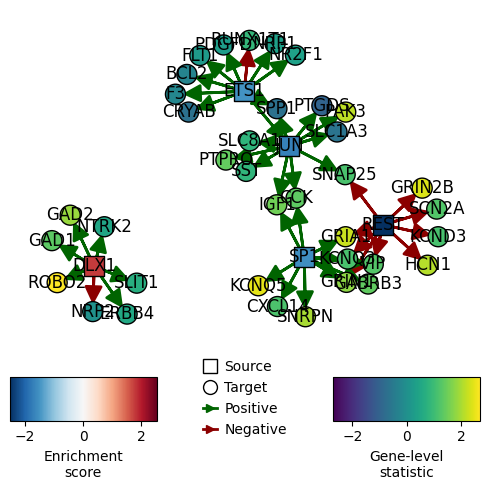

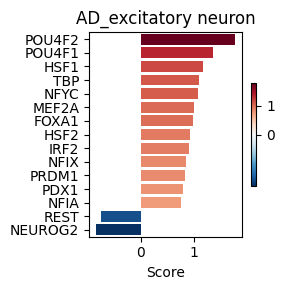

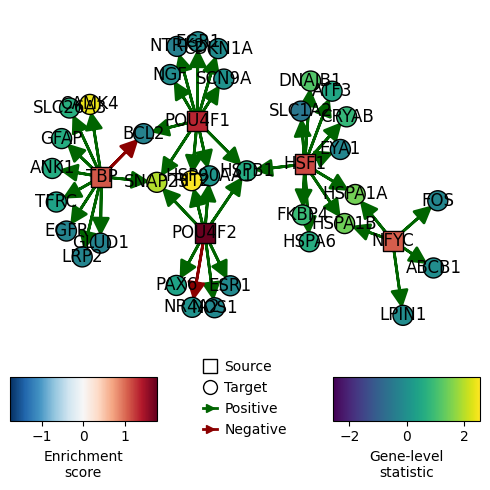

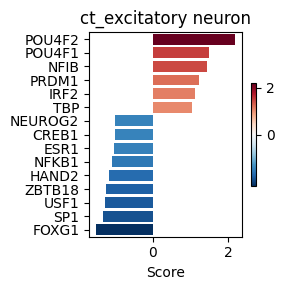

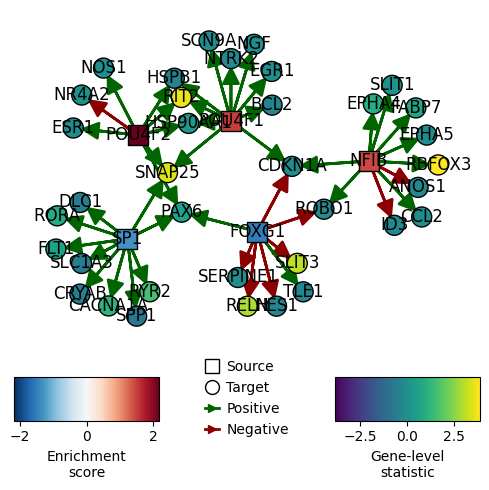

In [210]:
for ct in adata.obs["cell_type"].unique():
    ct_adata = adata[adata.obs["cell_type"]==ct].copy()
    for cond in adata.obs["oupSample.batchCond"].unique():
        ct_cond_adata = ct_adata[ct_adata.obs["oupSample.batchCond"]== cond].copy()
        dc.mt.ulm(data=ct_cond_adata, net=collectri)
        data = dc.pp.get_obsm(adata=ct_cond_adata, key="score_ulm")
        tf_activities = data.X.mean(0)
        tf_activities = pd.DataFrame(tf_activities.reshape(1,-1),index=["0"],columns=data.var.index)
        dc.pl.barplot(data=tf_activities, name="0", figsize=(3, 3),top=15)
        plt.title(f"{cond}_{ct}")

        gex_ct = ct_cond_adata.to_df().mean(0).to_frame().T
        score = dc.pp.get_obsm(adata=ct_cond_adata, key="score_ulm")
        score_ct = score.to_df().mean(0).to_frame().T
        sources = tf_activities.dropna(axis=1).abs().T.sort_values(by="0",ascending=False)[:5].index.to_list()
        dc.pl.network(
            net=collectri,
            data=gex_ct,
            score=score_ct,
            sources=sources,
            targets=10,
            figsize=(5, 5),
            vcenter=True,
            by_abs=True,
            size_node=5,
            t_label="Gene-level\nstatistic",
        )

In [32]:
dc.op.show_resources()

,name,license
0,Adhesome,commercial
1,Almen2009,commercial
2,Baccin2019,academic
3,CORUM_Funcat,academic
4,CORUM_GO,academic
...,...,...
76,iTALK,academic
77,kinase.com,non_profit
78,scConnect,commercial
79,scConnect_complex,commercial


In [153]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


In [155]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


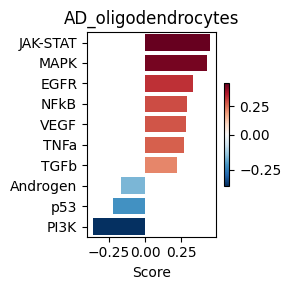

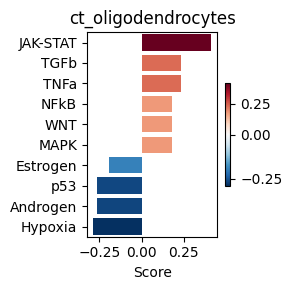

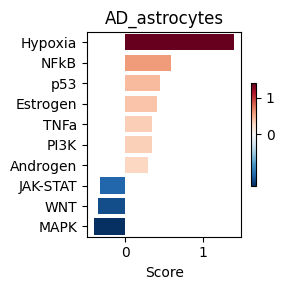

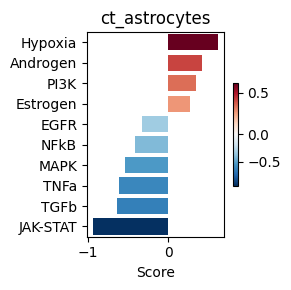

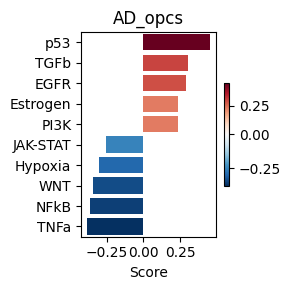

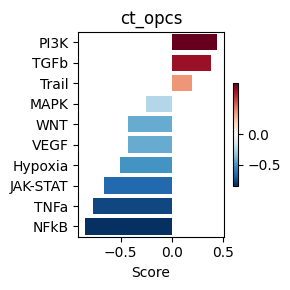

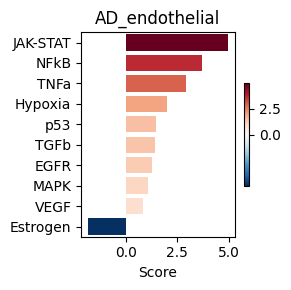

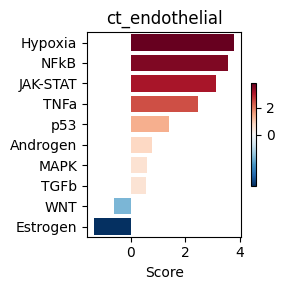

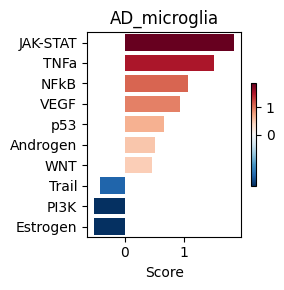

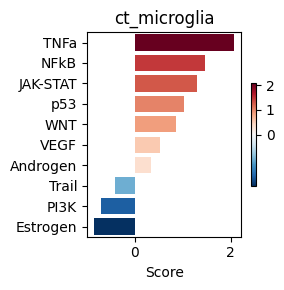

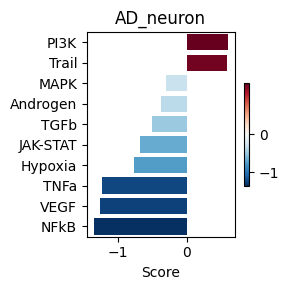

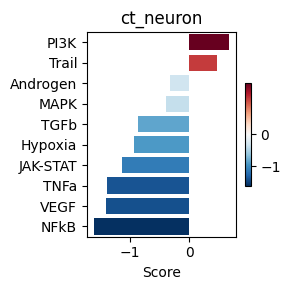

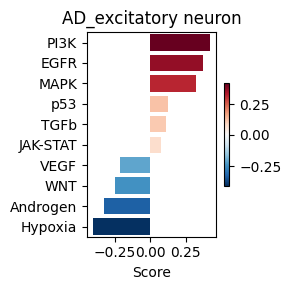

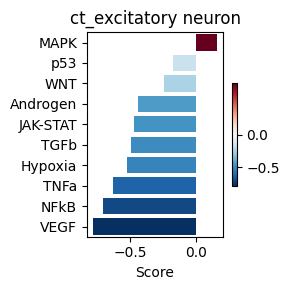

In [207]:
for ct in adata.obs["cell_type"].unique():
    ct_adata = adata[adata.obs["cell_type"]==ct].copy()
    for cond in adata.obs["oupSample.batchCond"].unique():
        ct_cond_adata = ct_adata[ct_adata.obs["oupSample.batchCond"]== cond].copy()
        dc.mt.ulm(data=ct_cond_adata, net=progeny)
        data = dc.pp.get_obsm(adata=ct_cond_adata, key="score_ulm")
        pw_activities = data.X.mean(0)
        pw_activities = pd.DataFrame(pw_activities.reshape(1,-1),index=["0"],columns=data.var.index)
        dc.pl.barplot(data=pw_activities, name="0", figsize=(3, 3),top=10)
        plt.title(f"{cond}_{ct}")

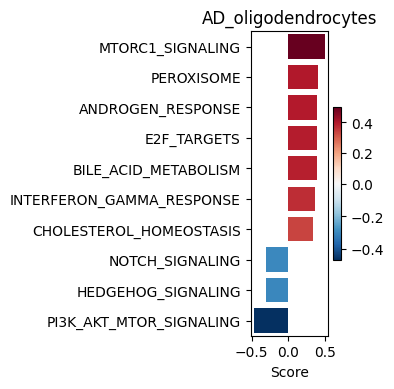

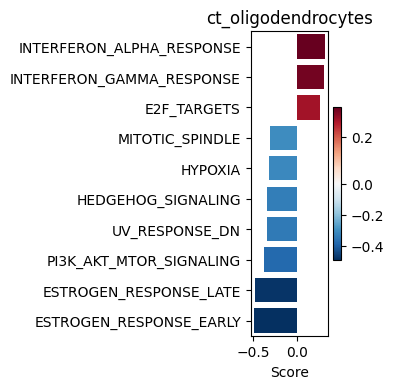

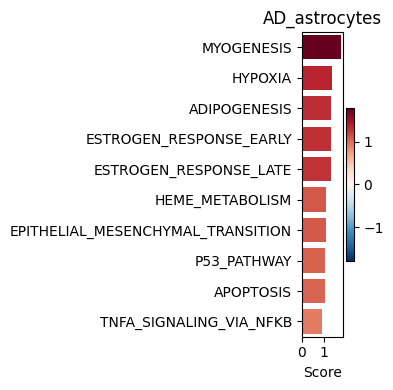

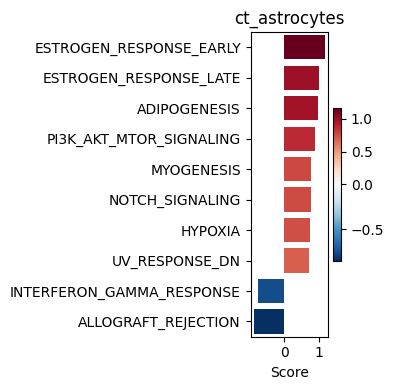

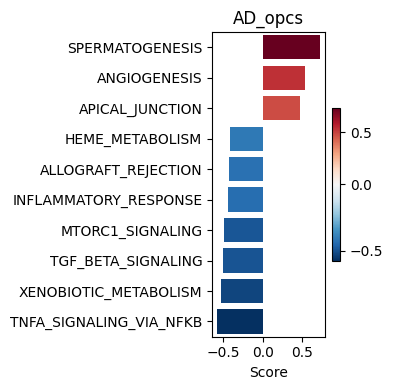

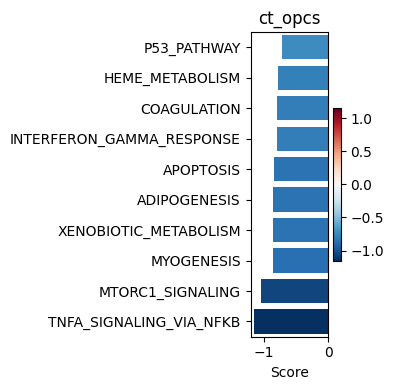

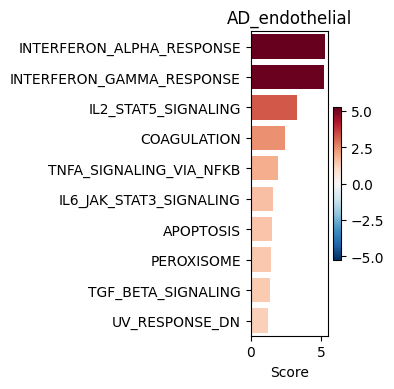

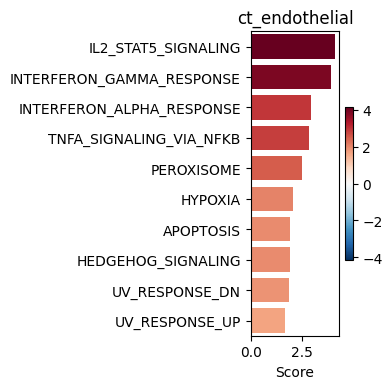

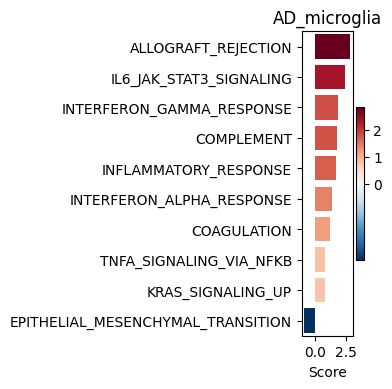

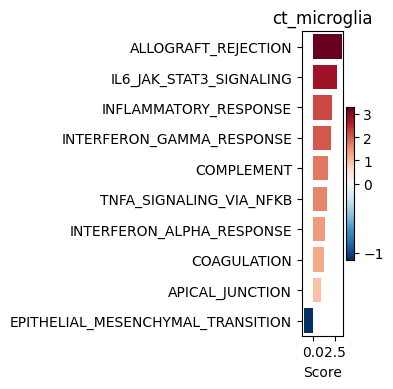

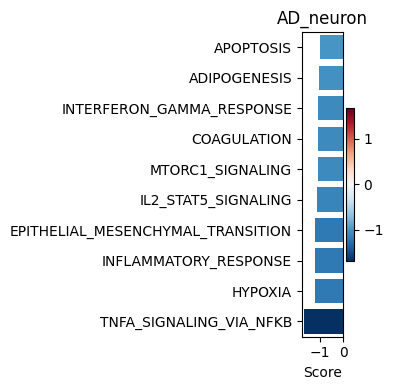

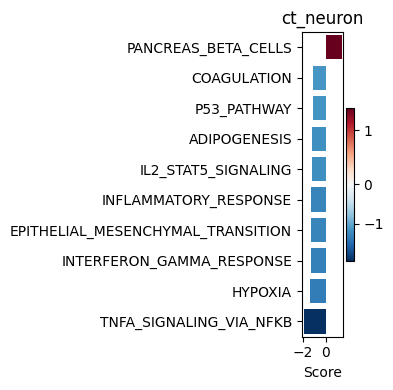

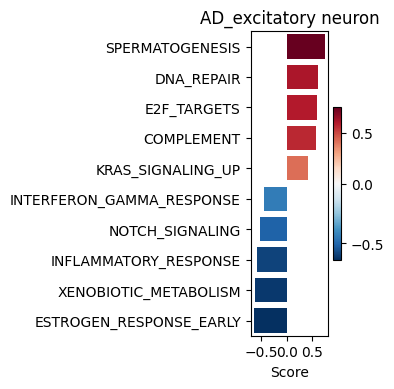

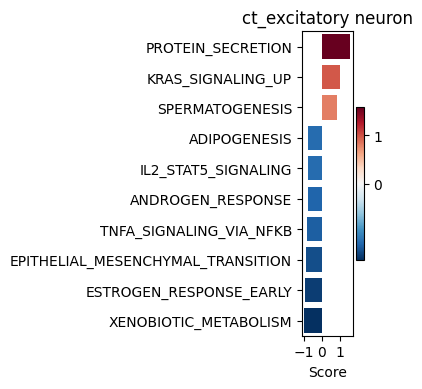

In [208]:
for ct in adata.obs["cell_type"].unique():
    ct_adata = adata[adata.obs["cell_type"]==ct].copy()
    for cond in adata.obs["oupSample.batchCond"].unique():
        ct_cond_adata = ct_adata[ct_adata.obs["oupSample.batchCond"]== cond].copy()
        dc.mt.ulm(data=ct_cond_adata, net=hallmark)
        data = dc.pp.get_obsm(adata=ct_cond_adata, key="score_ulm")
        hm_activities = data.X.mean(0)
        hm_activities = pd.DataFrame(hm_activities.reshape(1,-1),index=["0"],columns=data.var.index)
        dc.pl.barplot(data=hm_activities, name="0", figsize=(4, 4),top=10)
        plt.title(f"{cond}_{ct}")